In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("C:/Users/josem/Downloads/merged_dataset.csv")
df2 = pd.read_csv("C:/Users/josem/Downloads/P_Data_Extract_From_World_Development_Indicators (2)/0dcadbc7-bd26-4ddd-9cac-4190ed12a6a0_Data.csv")


In [84]:
# Filter for Armed forces personnel data for 2020
armed_forces_2020 = df2[df2['Series Name'] == 'Armed forces personnel (% of total labor force)']
armed_forces_2020 = armed_forces_2020[['Country Name', '2020 [YR2020]']]

# Clean the data - remove missing values and convert to numeric
armed_forces_2020 = armed_forces_2020.dropna()
armed_forces_2020['2020 [YR2020]'] = pd.to_numeric(armed_forces_2020['2020 [YR2020]'], errors='coerce')
armed_forces_2020 = armed_forces_2020.dropna()

#print(f"Number of countries with data: {len(armed_forces_2020)}")
armed_forces_2020.head(10)

,Country Name,2020 [YR2020]
2,Albania,0.591541
5,Austria,0.499148
8,Belarus,3.172507
11,Belgium,0.468319
14,Bosnia and Herzegovina,0.791178
17,Bulgaria,1.184524
20,Canada,0.351128
23,China,0.331880
26,Croatia,1.170877
29,Denmark,0.494720


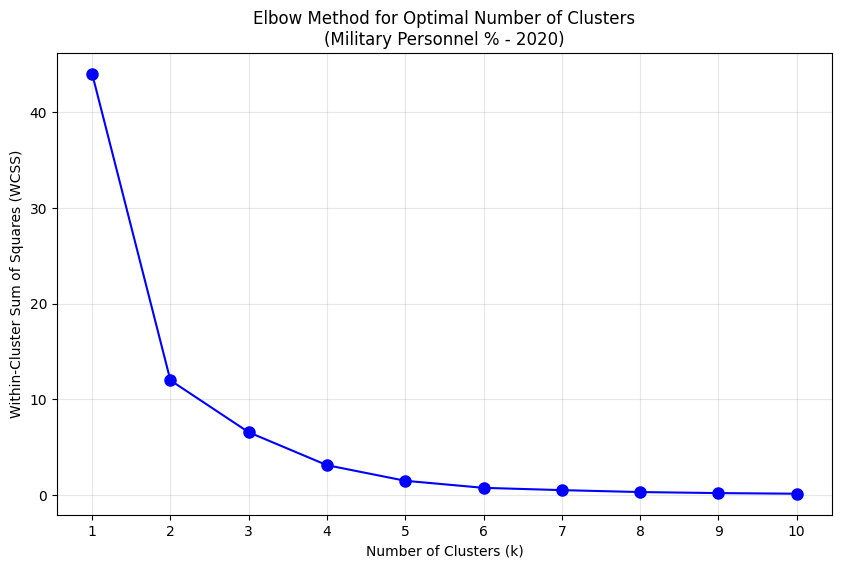

In [89]:
# Prepare data for clustering
X = armed_forces_2020[['2020 [YR2020]']].values

# Standardize the data (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate WCSS for different numbers of clusters
wcss = []
k_range = range(1, 11)  # Test 1 to 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal Number of Clusters\n(Military Personnel % - 2020)')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

In [85]:

optimal_k = 3

# Perform K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the dataframe
armed_forces_2020['Cluster'] = clusters
armed_forces_2020['Cluster_Label'] = armed_forces_2020['Cluster'].map({0: 'Low', 1: 'Medium', 2: 'High'})

# Get cluster centers in original scale
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

print(f"Cluster Centers (original scale): {cluster_centers_original.flatten()}")

Cluster Centers (original scale): [0.67106424 3.67735251 1.79126248]


In [86]:
# Sort clusters by their center values
sorted_clusters = sorted(
    enumerate(cluster_centers_original.flatten()), 
    key=lambda x: x[1]
)

# Create mapping from cluster number to label
labels = ['Low', 'Medium', 'High']
cluster_label_map = {cluster_num: labels[i] for i, (cluster_num, _) in enumerate(sorted_clusters)}

# Apply the mapping to the dataframe
armed_forces_2020['Cluster_Label'] = armed_forces_2020['Cluster'].map(cluster_label_map)

# display results
print("="*60)
print("K-MEANS CLUSTERING RESULTS - Armed Forces Personnel % (2020)")
print("="*60)

for cluster_num, center_value in sorted_clusters:
    cluster_data = armed_forces_2020[armed_forces_2020['Cluster'] == cluster_num]
    print(f"\nCLUSTER {cluster_num} ({cluster_label_map[cluster_num]}):")
    print(f"Center: {center_value:.2f}%")
    print(f"Number of countries: {len(cluster_data)}")
    print(f"Countries: {', '.join(cluster_data['Country Name'].tolist())}")
    print(f"Range: {cluster_data['2020 [YR2020]'].min():.2f}% to {cluster_data['2020 [YR2020]'].max():.2f}%")
    print(f"Average: {cluster_data['2020 [YR2020]'].mean():.2f}%")

# Summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Total countries analyzed: {len(armed_forces_2020)}")
print(f"Global average: {armed_forces_2020['2020 [YR2020]'].mean():.2f}%")
print(f"Global range: {armed_forces_2020['2020 [YR2020]'].min():.2f}% to {armed_forces_2020['2020 [YR2020]'].max():.2f}%")


K-MEANS CLUSTERING RESULTS - Armed Forces Personnel % (2020)

CLUSTER 0 (Low):
Center: 0.67%
Number of countries: 35
Countries: Albania, Austria, Belgium, Bosnia and Herzegovina, Bulgaria, Canada, China, Croatia, Denmark, Czechia, Estonia, Finland, France, Germany, Hungary, Latvia, Luxembourg, Mexico, Moldova, Poland, Portugal, Netherlands, Norway, Serbia, Slovenia, Slovak Republic, Spain, Sweden, Switzerland, United Kingdom, United States, Viet Nam, Japan, New Zealand, Australia
Range: 0.27% to 1.18%
Average: 0.67%

CLUSTER 2 (Medium):
Center: 1.79%
Number of countries: 6
Countries: Georgia, Italy, Lithuania, Romania, North Macedonia, Korea, Rep.
Range: 1.35% to 2.48%
Average: 1.79%

CLUSTER 1 (High):
Center: 3.68%
Number of countries: 3
Countries: Belarus, Greece, Montenegro
Range: 3.17% to 4.66%
Average: 3.68%

SUMMARY STATISTICS
Total countries analyzed: 44
Global average: 1.03%
Global range: 0.27% to 4.66%


C:\Users\josem\AppData\Local\Temp\ipykernel_40840\2080274527.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cluster_data, labels=cluster_labels)


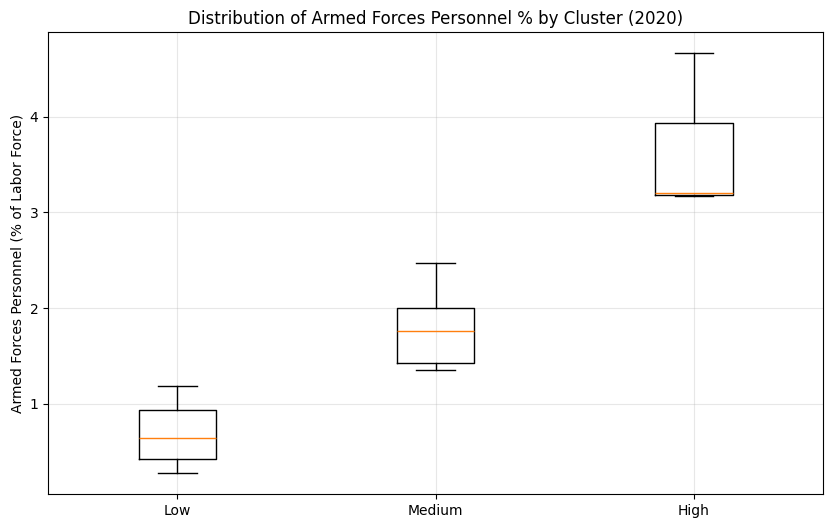

In [87]:
plt.figure(figsize=(10, 6))

# Sort clusters by their actual centers
sorted_clusters = sorted(
    enumerate(cluster_centers_original.flatten()),
    key=lambda x: x[1]
)

# Prepare data and labels in the correct order
cluster_data = []
cluster_labels = []

for cluster_num, _ in sorted_clusters:
    data = armed_forces_2020[armed_forces_2020['Cluster'] == cluster_num]['2020 [YR2020]']
    label = armed_forces_2020.loc[armed_forces_2020['Cluster'] == cluster_num, 'Cluster_Label'].iloc[0]
    cluster_data.append(data)
    cluster_labels.append(label)

# Create box plot
plt.boxplot(cluster_data, labels=cluster_labels)
plt.ylabel('Armed Forces Personnel (% of Labor Force)')
plt.title('Distribution of Armed Forces Personnel % by Cluster (2020)')
plt.grid(True, alpha=0.3)
plt.show()
